# 4 · Who wins a trade? Roll's estimator and the spread decomposition

**The questions:**
1. Can you estimate the spread from trade prices alone? (Roll 1984: yes, *if* the model holds.)
2. When a market maker earns the spread, does it keep it? Or does the price move against it straight
   after, so the "spread" was really payment for being picked off?

Question 2 is **adverse selection**, the central risk of market making: the people who trade with you
are, on average, slightly better informed than you.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, load_trades, aggregate_trades
from micro.book import mid, to_ms, resample_last
from micro.impact import mid_at, spread_decomposition
from micro.volatility import roll_spread
from micro.plotting import style, save, BLUE, ORANGE, GREEN, GREY, RED

style()
quotes = load_quotes()
trades = load_trades()
orders = aggregate_trades(trades)
qts, m = to_ms(quotes.ts), mid(quotes)

## Part 1: Roll's model

Roll's assumptions: the efficient price m_t is a random walk, and each trade prints at m_t ± s/2 depending
on whether it's a buy or a sell. Trade directions are **independent coin flips**. Then

$$\Delta p_t = \Delta m_t + \tfrac{s}{2}(q_t - q_{t-1}) \quad\Rightarrow\quad \mathrm{Cov}(\Delta p_t, \Delta p_{t-1}) = -\frac{s^2}{4}$$

so s = 2√(−Cov). (Derive it yourself: only the q_{t−1} terms overlap, giving −(s/2)²·Var(q) = −s²/4.)

**First, check the estimator works when the model is true:**

In [2]:
rng = np.random.default_rng(0)
n, true_s = 1_000_000, 0.1
m_sim = 70_000 + np.cumsum(rng.normal(0, 0.5, n))
q_sim = rng.choice([-1, 1], n)
print(f"simulated Roll model, true spread {true_s}: estimate = {roll_spread(m_sim + true_s / 2 * q_sim):.4f}")

simulated Roll model, true spread 0.1: estimate = 0.1037


Even with the random-walk moves ten times bigger than the spread, it recovers 0.1. Now real data:

In [3]:
print(f"true quoted spread: {np.median(quotes.ask - quotes.bid):.1f} USDT (99% of the time)")
print(f"Roll estimate from all fills:            {roll_spread(trades.price.to_numpy()):.2f} USDT")
print(f"Roll estimate from orders (first price): {roll_spread(orders.first_price.to_numpy()):.2f} USDT")
hourly = trades.groupby(trades.ts.dt.hour).price.apply(lambda x: roll_spread(x.to_numpy()))
print("\nRoll estimate by hour (fills):")
print(hourly.round(2).to_string())

true quoted spread: 0.1 USDT (99% of the time)
Roll estimate from all fills:            3.44 USDT
Roll estimate from orders (first price): 9.81 USDT



Roll estimate by hour (fills):
ts
0     2.18
1     0.61
2     0.84
3     0.49
4     0.49
5     0.23
6     0.07
7     1.32
8     0.40
9     0.85
10    0.37
11    0.78
12    0.12
13    4.80
14    5.46
15    2.85
16    3.82
17    3.49
18    1.15
19    0.26
20    0.77
21    0.19
22    0.51
23    1.39


**It fails badly**: 3–10 USDT instead of 0.1. In quiet hours (e.g. 06:00) it gets within the right order of
magnitude. Around the US open it's 50x too large.

Why? The model's assumptions are broken in two ways we've already seen:
- **Sweeps** (chapter 0): a large order prints fills several dollars through the book, then the next small
  trade prints back near the touch. That's a large move followed by a large reversal, i.e. a big negative
  covariance that Roll reads as a giant "bounce".
- **Signs aren't independent** (chapter 2). Persistent signs make consecutive trades print on the *same*
  side, which mutes the bounce and pushes the estimate the other way. Here the sweep effect wins.

The lesson isn't "Roll is useless". It's widely used on daily stock data where nothing else exists, and in
quiet periods it's in the right ballpark. The lesson is: **every estimator is a model, and a model's
assumptions are testable.** We checked it on simulated data where it's true, then on real data where it isn't.

## Part 2: decomposing the spread, i.e. adverse selection measured directly

For each aggressive order with sign s (+1 buy), price p (its VWAP), mid **before** the order m₀ and mid
a horizon h **after**, m_h:

| quantity | formula | meaning |
|---|---|---|
| effective spread | 2·s·(p − m₀) | what the taker paid relative to fair value (×2 to compare with the quoted spread) |
| price impact | 2·s·(m_h − m₀) | how far the price moved *in the taker's favour* afterwards = the maker's loss to information |
| realized spread | 2·s·(p − m_h) | what the maker actually kept once the dust settled |

effective = realized + impact. If realized spread < 0, makers **lose** money on average on these trades
(before exchange fees and rebates).

We keep the 97% of orders whose first fill was at the prevailing best quote. The other 3% have stale
"before" quotes (chapter 0) and would contaminate m₀.

In [4]:
ots = to_ms(orders.ts)
bid0 = resample_last(qts, quotes.bid.to_numpy(), ots - np.timedelta64(1, "ms"))
ask0 = resample_last(qts, quotes.ask.to_numpy(), ots - np.timedelta64(1, "ms"))
sign = orders.sign.to_numpy()
touch = np.where(sign == 1, ask0, bid0)
clean = np.abs(orders.first_price.to_numpy() - touch) < 1e-6
print(f"orders kept: {clean.mean():.1%}")

o = orders[clean].reset_index(drop=True)
ots, sign, qty, price, m0 = ots[clean], sign[clean], o.qty.to_numpy(), o.vwap.to_numpy(), ((bid0 + ask0) / 2)[clean]

horizons_ms = [0, 100, 1000, 5000, 10_000, 60_000, 300_000]
rows, decomp_5s = [], None
for h in horizons_ms:
    mh = mid_at(qts, m, ots + np.timedelta64(h, "ms"))
    d = spread_decomposition(price, sign, m0, mh)
    if h == 5000:
        decomp_5s = d
    rows.append({"horizon": f"{h / 1000:g}s",
                 "effective": np.mean(d["effective"]), "impact": np.nanmean(d["impact"]), "realized": np.nanmean(d["realized"]),
                 "realized, BTC-weighted": np.nansum(d["realized"] * qty) / qty.sum()})
table = pd.DataFrame(rows).set_index("horizon")
print("Average per order, USDT (spread = 0.1 USDT):")
print(table.round(3))

orders kept: 96.8%

Average per order, USDT (spread = 0.1 USDT):
         effective  impact  realized  realized, BTC-weighted
horizon                                                     
0s           0.692   0.466     0.226                   2.276
0.1s         0.692   2.129    -1.437                  -6.282
1s           0.692   3.343    -2.651                  -8.818
5s           0.692   3.827    -3.136                  -9.964
10s          0.692   3.921    -3.230                  -9.480
60s          0.692   3.465    -2.773                  -7.712
300s         0.692   0.949    -0.257                  -6.964


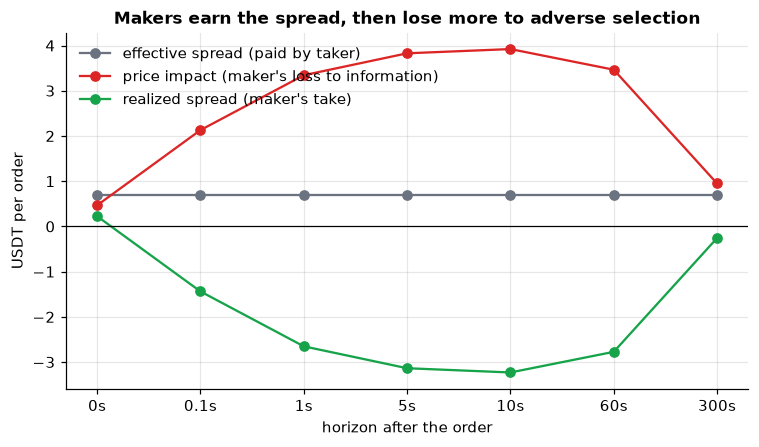

In [5]:
fig, ax = plt.subplots()
x = np.arange(len(horizons_ms))
ax.plot(x, table["effective"], "o-", color=GREY, label="effective spread (paid by taker)")
ax.plot(x, table["impact"], "o-", color=RED, label="price impact (maker's loss to information)")
ax.plot(x, table["realized"], "o-", color=GREEN, label="realized spread (maker's take)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, table.index)
ax.set(xlabel="horizon after the order", ylabel="USDT per order", title="Makers earn the spread, then lose more to adverse selection")
ax.legend()
save(fig, "04_spread_decomposition")

Read the plot left to right:

- The taker pays an effective spread of about 0.7 USDT on average (most orders pay 1 tick = 0.1; sweeps pay much more).
- Within **100 ms**, the mid has already moved about 2 USDT in the taker's direction, and by 5–10 s about 4 USDT.
- So the **realized spread is negative** at every horizon from 100 ms on. On average, a maker who got filled
  would have been better off not trading.
- At 5 minutes the equal-weighted impact shrinks back toward zero (some of the move reverses), but the
  BTC-weighted realized spread stays deeply negative: **big orders carry permanent information**.

### Is it all orders, or a few big ones?

In [6]:
dec = pd.qcut(qty, 5)
by_size = pd.DataFrame({k: v for k, v in decomp_5s.items()}).groupby(dec, observed=True).agg(["mean", "median"])
print("Spread decomposition at 5 s by order size (BTC quintiles), USDT:")
print(by_size.round(3))
print(f"\nshare of orders after which the mid moved WITH the taker within 5 s:    {np.mean(decomp_5s['impact'] > 0):.1%}")
print(f"share of orders after which the mid moved AGAINST the taker within 5 s: {np.mean(decomp_5s['impact'] < 0):.1%}")

Spread decomposition at 5 s by order size (BTC quintiles), USDT:
               effective        impact        realized       
                    mean median   mean median     mean median
(0.0, 0.004]       0.308    0.1  1.377    0.0   -1.069    0.1
(0.004, 0.013]     0.403    0.1  1.856    0.2   -1.452   -0.1
(0.013, 0.04]      0.531    0.1  2.994    1.6   -2.463   -1.3
(0.04, 0.158]      0.616    0.1  4.103    3.2   -3.487   -2.9
(0.158, 225.0]     1.604    0.1  8.838    7.4   -7.234   -6.3

share of orders after which the mid moved WITH the taker within 5 s:    52.5%
share of orders after which the mid moved AGAINST the taker within 5 s: 43.2%


- **Means**: impact grows with size and swamps the effective spread in *every* size bucket, even the smallest orders.
- **Medians**: the typical (median) order has zero impact. The maker earns its tick and nothing happens.

So adverse selection is a **tail** phenomenon: most fills are harmless, but a minority arrive just before
the price runs, and those losses outweigh all the ticks earned. A maker's edge comes from avoiding the
toxic minority: pulling quotes when imbalance or order flow signals a move (chapters 5 and 6), and from
being early in the queue. It's also why exchanges pay maker rebates, and why the most active market makers
on large-tick markets compete so hard on latency.

Small orders show impact too, not because a 0.002 BTC order moves the market, but because small orders
arrive *alongside* big ones in bursts of same-direction flow (chapter 2). Impact here is "what happened
next", not "what this order caused". Separating the two needs a model (chapter 7).

---
### Interview angle

<details><summary><b>"You're a market maker and you just got lifted on your offer. What do you do?"</b></summary>

Update your fair value up: the buyer may know something (this chapter: the mid moves with the taker on
average). Typically raise both bid and ask (skew). How much depends on how informative trades are, i.e. the
impact per unit size. This is the Glosten–Milgrom / Kyle logic in practice.
</details>

<details><summary><b>"Derive the Roll estimator."</b></summary>

p_t = m_t + (s/2)q_t with q_t i.i.d. ±1 and independent of Δm. Δp_t = Δm_t + (s/2)(q_t − q_{t−1}). In
Cov(Δp_t, Δp_{t−1}) only the q_{t−1} terms overlap: (s/2)·(−q_{t−1}) times (s/2)·q_{t−1}, so
Cov = −(s²/4)·E[q²] = −s²/4, hence s = 2√(−Cov). If Cov > 0, the model is rejected and the estimate is undefined.
</details>

<details><summary><b>"What's the difference between quoted, effective and realized spread?"</b></summary>

Quoted: ask − bid on the screen. Effective: what takers actually paid vs the mid (can be lower with hidden
liquidity or price improvement, or higher for sweeps). Realized: effective minus subsequent price impact, i.e.
what liquidity providers kept. Effective − realized = adverse selection.
</details>

### Try this yourself
1. Simulate a Roll model where signs are *persistent* (P(same as last) = 0.6). Is Roll biased up or down? By how much?
2. Recompute the 5 s decomposition separately for 03:00–04:00 and 13:00–14:00. When is market making more toxic?